In [1]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from perturbation_plds import (
    fit_perturbation_plds, fit_perturbation_plds_no_dG,
    fit_perturbation_plds_intrinsic, evaluate_perturbation_plds,
    crossval_compare_models,
)

%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'autograd'

In [ ]:
selected_window = 168
vector_full_record_all = []
for session_num in range(0,1):
    with open(f'/home/sp645/isilon/All_Staff/sp645/data/Yi_deconvoled_calcium/Ephys_no_smooth/session{session_num}.pkl', "rb") as f:   # "rb" = read, binary
        obj = pickle.load(f)
    print(type(obj))
    print(obj.keys())
    behavior = obj['behavior'][:, :selected_window, :]
    train_data = obj['train'][:, :selected_window, :]
    test_data = obj['test']

    print(behavior.shape, train_data.shape)

    Y = behavior[:,:, :2]
    velocity = Y[:, 1:, :] - Y[:, :-1, :]
    U = behavior[:,:, 2]
    X_flatten = train_data.reshape((-1, train_data.shape[-1]))
    #factors_normalized = (X_flatten - X_flatten.min()) / (X_flatten.max() - X_flatten.min())
    #print(Y.shape, U.shape, X_flatten.shape, velocity.shape)


    velocity = np.concatenate([velocity, np.zeros((train_data.shape[0], 1 ,2))],axis = 1)
    Z = np.concatenate([Y, velocity],axis = -1)
    U = U
    X = train_data
    print(Z.shape, U.shape, X.shape)

    res = fit_perturbation_plds(Z, X, U, p=5, J=3,
                            lam_G=1e-3, lam_dG=1e-3)
    print(res["dG_lag"].shape)   # (J+1, p, d_z) — the perturbation gain

    metrics = evaluate_perturbation_plds(res, Z, X, U)

    # Scientific test: does δG improve held-out fit? (folds split by TRIAL)
    cv = crossval_compare_models(Z, X, U, p=5, J=3, n_folds=5,
                                models=("full", "no_dG", "intrinsic"))
    for m in cv:
        print(m, cv[m]["mean"]["deviance_x_per_obs"]) 

    # mean_control = np.mean(X[non_deviation_trial_index], axis=0)

<class 'dict'>
dict_keys(['train', 'test', 'behavior'])
(140, 168, 3) (140, 168, 91)
(140, 168, 4) (140, 168) (140, 168, 91)


ARHMM Initialization restarts:   0%|          | 0/1 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


ELBO: -907613.0: 100%|██████████| 100/100 [10:45<00:00,  6.46s/it]


(4, 5, 4)


KeyboardInterrupt: 

In [6]:
metrics

{'deviance_x': 1132755.7365294453,
 'deviance_x_per_obs': 0.5421544092590292,
 'loglik_x': -910155.6426329507,
 'pseudoR2_x': 0.12779349679171914,
 'held_out_marginal_likelihood': -907831.832551488,
 'n_obs': 2089360}

In [12]:
res.keys()

dict_keys(['F', 'Q', 'm_s', 'G_lag', 'dG_lag', 'C', 'b', 'p', 'J', 'dt', 'log_marginal_likelihood_trace', '_ssm_model', '_meta'])

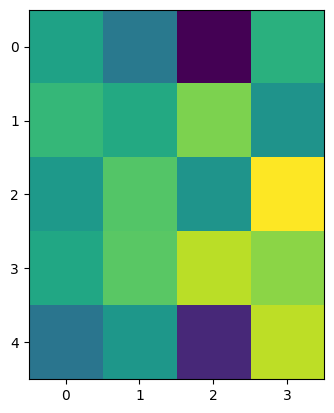

In [13]:
plt.imshow(res['G_lag'][0])#res.keys()